In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/8th Semester (final project )/NewFeatures/Real vs Fake/DataSets/WELFake_Dataset.csv')

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (72134, 4)


In [6]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


#badLINEs

In [7]:
bad_lines = []

# Define a function to collect the problematic rows
def collect_bad_lines(bad_line_list):
    bad_lines.append(bad_line_list)
    return None  # Returning None tells Pandas to skip the line after capturing it

In [8]:
# Load the dataset using the callback
df = pd.read_csv('/content/drive/MyDrive/8th Semester (final project )/NewFeatures/Real vs Fake/DataSets/WELFake_Dataset.csv',
                 on_bad_lines=collect_bad_lines,
                 engine='python')

# Print how many bad lines were found
print(f"Total problematic lines found: {len(bad_lines)}")

Total problematic lines found: 25


In [9]:
for i, line in enumerate(bad_lines[:]):
    print(f"\nBad Line {i+1}: {line}")


Bad Line 1: ['Scandinavian countries can do ok with socialism because of their high functioning populace. They’re smarter and have a better culture in terms of work ethic', ' norms about work', ' etc', ' on average. They also live in tiny homes and drive tiny cars to achieve some of this “prosperity”. They also don’t have much military spending', ' which is why they were conquered in a few weeks the last time anyone tried. A uniform ethnic makeup has helped with cultural issues of socialism as well', ' though this is changing. ']

Bad Line 2: ['Вы сейчас мне скажете', ' Вы сказали: в Крыму. А что в Крыму? Что Вы сделали в Югославии и потом отделили от неё часть государств', ' в том числе и Косово', ' а потом от Сербии. В Косово парламент проголосовал после военных действий интервенции', ' после многочисленных жертв. И всё', ' решение принято', ' и все с этим согласились.']

Bad Line 3: ['В Крыму не было никакой войны. Не было никаких бомбовых ударов', ' военных действий', ' жертв нет'

#skiiping Badlines

In [10]:
path = '/content/drive/MyDrive/8th Semester (final project )/NewFeatures/Real vs Fake/DataSets/WELFake_Dataset.csv'

try:
    df = pd.read_csv(path, on_bad_lines='skip', engine='python')
    print(f"Successfully loaded {len(df)} rows. Bad lines were skipped.")
except Exception as e:
    print(f"Error: {e}")

Successfully loaded 72154 rows. Bad lines were skipped.


In [11]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [12]:
df.shape

(72154, 4)

#finding Null Values

In [13]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Unnamed: 0      0
title         565
text           57
label          20
dtype: int64


In [14]:
print("--- Samples with Missing Titles ---")
display(df[df['title'].isnull()].head(5))

--- Samples with Missing Titles ---


,Unnamed: 0,title,text,label
1,1,NaN,Did they post their votes for Hillary already?,1
43,43,NaN,True. Hillary needs a distraction and what bet...,1
162,162,NaN,All eyes on Electoral delegates. The People kn...,1
185,185,NaN,Cool,1
269,269,NaN,A leading US senator: US Supporting War in Syr...,1


In [15]:
print("\n--- Samples with Missing Text ---")
display(df[df['text'].isnull()].head(5))


--- Samples with Missing Text ---


,Unnamed: 0,title,text,label
327,The problem wouldn’t exist if people lived by ...,None,None,None
328,Unfortunately,most Americans would rather commit mass suici...,None,None
330,Possibly up to 5% of the US debt burden at all...,favoritism and cronyism do the rest…,None,None
331,Anyway,here is an example of a Canadian with US Citi...,None,None
332,http://groups.yahoo.com/group/Australian-marry...,None,None,None


#null value removed

In [16]:
# Remove rows where title or text is missing
#df = df.dropna(subset=['title', 'text'])

# Combine title + text
df['content'] = df['title'] + ' ' + df['text']

In [17]:
df = df.dropna(subset=['content', 'label'])
#df['text'] = df['text'].fillna(' ')

In [18]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Unnamed: 0    0
title         0
text          0
label         0
content       0
dtype: int64


In [19]:
print("\n--- Samples with Missing Text ---")
display(df[df['text'].isnull()].head(5))


--- Samples with Missing Text ---


,Unnamed: 0,title,text,label,content


In [20]:
df.head()

,Unnamed: 0,title,text,label,content
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,About Time! Christian Group Sues Amazon and SP...


#Finding other languages

In [21]:
!pip install langdetect
from langdetect import detect
def quick_lang_check(content):
    try:
        # We only check the first 200 characters for speed
        return detect(content[:200])
    except:
        return "unknown"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=2e84dd4432abbe3aa8886c0569c671c1d349c66596ed612a681ce25238bafad9
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [22]:
sample_df = df.sample(5000, random_state=42).copy()

In [23]:
sample_df.columns

Index(['Unnamed: 0', 'title', 'text', 'label', 'content'], dtype='object')

In [24]:
sample_df['detected_lang'] = sample_df['content'].apply(quick_lang_check)

In [25]:
print(sample_df['detected_lang'].value_counts())

detected_lang
en         4965
de           13
es            8
ru            8
fr            4
unknown       1
ro            1
Name: count, dtype: int64


In [26]:
df['detected_lang'] = df['content'].apply(quick_lang_check)

# Keep only English rows
df = df[df['detected_lang'] == 'en'].copy()

# Double-check
print(df['detected_lang'].value_counts())

detected_lang
en    70971
Name: count, dtype: int64


In [27]:
df.shape

(70971, 6)

In [28]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label', 'content', 'detected_lang'], dtype='object')

In [29]:
df.head()

,Unnamed: 0,title,text,label,content,detected_lang
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,en
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,en
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri...",en
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...,en
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,About Time! Christian Group Sues Amazon and SP...,en


In [30]:
sample_df = df.sample(5000, random_state=42).copy()
sample_df['detected_lang'] = sample_df['content'].apply(quick_lang_check)
print(sample_df['detected_lang'].value_counts())

detected_lang
en    5000
Name: count, dtype: int64


#Got, samll noises. That can cause issues.

In [31]:
from langdetect import detect

# Improved function: use more text for detection
def robust_lang_check(content):
    try:
        # Instead of just 200 chars, use up to 500 for better accuracy
        return detect(content[:500])
    except:
        return "unknown"

# Apply to your DataFrame
df['detected_lang'] = df['content'].apply(robust_lang_check)

# Keep only English rows
df = df[df['detected_lang'] == 'en'].copy()

# Double-check
print(df['detected_lang'].value_counts())


detected_lang
en    70961
Name: count, dtype: int64


In [32]:
df['detected_lang'].head()

,detected_lang
0,en
2,en
3,en
4,en
5,en


In [33]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label', 'content', 'detected_lang'], dtype='object')

#small noises fixed. Dataset review is finished.

##pre_processing

In [34]:
# Keep only English rows
df = df[df['detected_lang'] == 'en'].copy()

# Keep only required columns
df = df[['content', 'label', 'detected_lang']]

# Reset index
df.reset_index(drop=True, inplace=True)

# Preview
print(df.head())

# Shape
print(df.shape)

                                             content label detected_lang
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...     1            en
1  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...     1            en
2  Bobby Jindal, raised Hindu, uses story of Chri...     0            en
3  SATAN 2: Russia unvelis an image of its terrif...     1            en
4  About Time! Christian Group Sues Amazon and SP...     1            en
(70961, 3)


In [35]:
df.tail()

,content,label,detected_lang
70956,Russians steal research on Trump in hack of U....,0,en
70957,WATCH: Giuliani Demands That Democrats Apolog...,1,en
70958,Migrants Refuse To Leave Train At Refugee Camp...,0,en
70959,Trump tussle gives unpopular Mexican leader mu...,0,en
70960,Goldman Sachs Endorses Hillary Clinton For Pre...,1,en


In [36]:
df.columns

Index(['content', 'label', 'detected_lang'], dtype='object')

In [37]:
print(df['detected_lang'].value_counts())
print(df['content'].value_counts())
print(df['label'].value_counts())

detected_lang
en    70961
Name: count, dtype: int64
content
Highlights: The Trump presidency on April 13 at 9:30 P.M. EDT/0130 GMT on Friday (Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a massive GBU-43 bomb, the largest non-nuclear bomb it has ever used in combat, in Afghanistan against a series of caves used by Islamic State militants, the Pentagon says. Trump says Pyongyang is a problem that “will be taken care of” amid speculation that North Korea is on the verge of a sixth nuclear test. Military force cannot resolve tension over North Korea, China warns, while an influential Chinese newspaper urges Pyongyang to halt its nuclear program in exchange for Beijing’s protection. The Trump administration is focusing its North Korea strategy on tougher economic sanctions, possibly including intercepting cargo ships and punishing Chinese banks doing business with Pyongyang, U.S. officials say. Trump says “things will work out 

###got corrupted label

In [38]:
print(df['label'].dtype)

object


In [39]:
bad_rows = df[~df['label'].isin([0, 1])]
print(bad_rows[['content', 'label']].head())

                                             content label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...     1
1  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...     1
2  Bobby Jindal, raised Hindu, uses story of Chri...     0
3  SATAN 2: Russia unvelis an image of its terrif...     1
4  About Time! Christian Group Sues Amazon and SP...     1


In [40]:
print(df['label'].unique()[:10])

['1' '0' ' is just unbelievably rich from North Sea oil. ']


In [41]:
#bad_rows['label_length'] = bad_rows['label'].astype(str).apply(len)
#print(bad_rows[['label', 'label_length']])

bad_rows = df[~df['label'].isin(['0', '1'])]
print("Corrupted rows:", len(bad_rows))

Corrupted rows: 1


In [42]:
print(bad_rows[['content', 'label']])

                                               content  \
318   also don’t forget the fact that the Scandinav...   

                                               label  
318   is just unbelievably rich from North Sea oil.   


In [43]:
df['label'] = pd.to_numeric(df['label'], errors='coerce')

df = df.dropna(subset=['label'])

df['label'] = df['label'].astype(int)

In [44]:
print(df['label'].unique()[:])

[1 0]


In [45]:
print(df['label'].dtype)

int64


##resolved!!!

#checking content conatins duplicate values

In [46]:
print(df['content'].duplicated().sum())

8388


In [47]:
duplicate_titles = df[df.duplicated(subset=['content'], keep=False)]

In [48]:
duplicate_titles = duplicate_titles.sort_values(by='content')

In [49]:
print(duplicate_titles[['content', 'label']])

                                                 content  label
34056  "Top Five Clinton Donors Are Jewish" - How Ant...      1
39717  "Top Five Clinton Donors Are Jewish" - How Ant...      1
14862  #2816: Clinton Pride’s 8(a) Pig Farm Bridge – ...      1
21985  #2816: Clinton Pride’s 8(a) Pig Farm Bridge – ...      1
1915   #AnyoneButHillary: NEW POLL Shows Bernie Suppo...      1
...                                                  ...    ...
43821  “YOU’RE HIRED!” Trump Pulls Unemployed Vet Fro...      1
35599  “You Ruined Your Own Communities, Don’t Ruin O...      1
43818  “You Ruined Your Own Communities, Don’t Ruin O...      1
65258  “You’re Not Welcome!” Obama As Welcome At Rose...      1
43523  “You’re Not Welcome!” Obama As Welcome At Rose...      1

[16247 rows x 2 columns]


In [50]:
print(df['content'].nunique())

62572


#removing only the duplicated content who has the duplicated label data

In [51]:
df = df.drop_duplicates(subset=['content', 'label'])

In [52]:
df.shape

(62572, 3)

In [53]:
print(df['content'].duplicated().sum())

0


In [54]:
print(df['content'].nunique())

62572


#checking conflicting, means conatining 0 and 1 both label

In [55]:
conflicting_titles = df.groupby('content')['label'].nunique()

conflicting_titles = conflicting_titles[conflicting_titles > 1]

print(conflicting_titles)

Series([], Name: label, dtype: int64)


In [56]:
conflicting_titles.head()

,label
content,


#if LAbel=2 shows "content" contains both 0 & 1 label

In [57]:
conflicting_titles = conflicting_titles.index

In [58]:
df = df[~df['content'].isin(conflicting_titles)]

In [59]:
df.reset_index(drop=True, inplace=True)

In [60]:
print(df.shape)

print(df['content'].nunique())

(62572, 3)
62572


In [61]:
df.columns

Index(['content', 'label', 'detected_lang'], dtype='object')

#removed the duplicated part...

###**nlp pre - processing**

In [62]:
print(df.isnull().sum())

content          0
label            0
detected_lang    0
dtype: int64


In [63]:
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [64]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

# Negation words — MUST be kept for fake news detection
negation_words = {'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere'}

# Remove negation words from stopword list
stop_words = stop_words - negation_words

print(f"Total stopwords: {len(stop_words)}")
print(f"Negation words preserved: {negation_words}")

Total stopwords: 195
Negation words preserved: {'nor', 'nowhere', 'no', 'nothing', 'never', 'not', 'nobody', 'neither'}


In [65]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """
    Map NLTK POS tag to WordNet POS tag.
    This ensures verbs like 'seizing' → 'seize' are correctly lemmatized.
    """
    if tag.startswith('V'):   return wordnet.VERB   # Verbs
    elif tag.startswith('J'): return wordnet.ADJ    # Adjectives
    elif tag.startswith('R'): return wordnet.ADV    # Adverbs
    else:                     return wordnet.NOUN   # Default: Noun

In [66]:
def preprocess_text(text):

    # Step 1: Convert to string (safety)
    text = str(text)

    # Step 2: Remove line breaks
    text = text.replace('\n', ' ').replace('\r', ' ')

    # Step 3: Lowercase
    text = text.lower()

    # Step 4: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 5: Keep only letters and spaces (remove numbers & punctuation)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 7: Tokenize
    words = text.split()

    # Step 8: Remove stopwords (negation words are SAFE)
    words = [word for word in words if word not in stop_words]

    # Step 9: POS-aware Lemmatization
    pos_tags = pos_tag(words)
    words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

    return ' '.join(words)

In [67]:
df['clean_title'] = df['content'].apply(preprocess_text)

In [68]:
df[['content', 'clean_title']].head(10)

,content,clean_title
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement high alert follow threat cop w...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama attorney general say charlo...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raise hindu us story christian co...
3,SATAN 2: Russia unvelis an image of its terrif...,satan russia unvelis image terrify new supernu...
4,About Time! Christian Group Sues Amazon and SP...,time christian group sue amazon splc designati...
5,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,dr ben carson target irs never audit speak nat...
6,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,house intel chair trump russia fake story no e...
7,Sports Bar Owner Bans NFL Games…Will Show Only...,sport bar owner ban nfl game show true america...
8,Latest Pipeline Leak Underscores Dangers Of Da...,late pipeline leak underscore danger dakota ac...
9,GOP Senator Just Smacked Down The Most Puncha...,gop senator smack punchable alt right nazi int...


In [69]:
df[['content', 'clean_title']].tail(10)

,content,clean_title
62562,Florida Judge Blames Rape Victim For Attendin...,florida judge blame rape victim attend music f...
62563,Swiss stop seizing income from asylum seekers ...,swiss stop seize income asylum seeker pay upke...
62564,"Dallas, Roger Federer, Hillary Clinton: Your F...",dallas roger federer hillary clinton friday ev...
62565,An Unlikely Contender Rises in France as the A...,unlikely contender rise france antithesis trum...
62566,Determined to kill: Can tough gun laws end mas...,determine kill tough gun law end mass shooting...
62567,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,wikileaks email show clinton foundation fund u...
62568,Russians steal research on Trump in hack of U....,russian steal research trump hack u democratic...
62569,WATCH: Giuliani Demands That Democrats Apolog...,watch giuliani demand democrat apologize trump...
62570,Migrants Refuse To Leave Train At Refugee Camp...,migrant refuse leave train refugee camp hungar...
62571,Trump tussle gives unpopular Mexican leader mu...,trump tussle give unpopular mexican leader muc...


#example Check

In [70]:
# Make sure negation words are NOT being removed
test_cases = [
    "vaccine is not safe",
    "no evidence found",
    "never happened before",
    "nobody knows the truth"
]

print(" Negation Word Preservation Check:\n")
for t in test_cases:
    print(f"  Original : {t}")
    print(f"  Cleaned  : {preprocess_text(t)}")
    print()

 Negation Word Preservation Check:

  Original : vaccine is not safe
  Cleaned  : vaccine not safe

  Original : no evidence found
  Cleaned  : no evidence find

  Original : never happened before
  Cleaned  : never happen

  Original : nobody knows the truth
  Cleaned  : nobody know truth



## labels 0 & 1

In [71]:
print(df['label'].value_counts())

label
0    34785
1    27787
Name: count, dtype: int64


In [72]:
min_count = df['label'].value_counts().min()

df_balanced = df.groupby('label').sample(n=min_count, random_state=42)

print(df_balanced['label'].value_counts())

label
0    27787
1    27787
Name: count, dtype: int64


X = df['clean_title'].values
###this generates the inconsistent numbers
y = df_balanced['label'].values #.astype(int).values

In [73]:
X = df_balanced['clean_title'].values
y = df_balanced['label'].values #.astype(int).values

In [74]:
print(df['label'].dtype)

int64


In [75]:
print(y.dtype)

int64


In [76]:
print(df[['clean_title', 'label']].head())

                                         clean_title  label
0  law enforcement high alert follow threat cop w...      1
1  unbelievable obama attorney general say charlo...      1
2  bobby jindal raise hindu us story christian co...      0
3  satan russia unvelis image terrify new supernu...      1
4  time christian group sue amazon splc designati...      1


##DataSplitting

In [77]:
import re, os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [78]:
# ── Step 1: 70% train | 30% temp ─────────────────────────────────────
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

In [79]:
# ── Step 2: 15% val | 15% test (split the temp 50/50) ────────────────
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

In [80]:
print(f'Train  : {len(X_train):,} samples  |  Fake: {(y_train==0).sum():,}  Real: {(y_train==1).sum():,}')
print(f'Val    : {len(X_val):,} samples   |  Fake: {(y_val==0).sum():,}  Real: {(y_val==1).sum():,}')
print(f'Test   : {len(X_test):,} samples   |  Fake: {(y_test==0).sum():,}  Real: {(y_test==1).sum():,}')

Train  : 38,901 samples  |  Fake: 19,450  Real: 19,451
Val    : 8,336 samples   |  Fake: 4,168  Real: 4,168
Test   : 8,337 samples   |  Fake: 4,169  Real: 4,168


###Tokenization + Sequence Encoding

In [81]:
##tokenization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [82]:
vocab_size = 20000

In [83]:
# ── Tokenizer — fit ONLY on training data (no leakage) ───────────────
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

If the model sees unseen words later, it maps safely to <OOV> instead of crashing semantic consistency.

In [84]:
tokenizer.fit_on_texts(X_train)

In [85]:
print(f'Vocabulary size (unique words): {len(tokenizer.word_index):,}')
print(f'Capped at: {vocab_size:,}')

Vocabulary size (unique words): 132,685
Capped at: 20,000


###"capped at" stand for "only using the most frequent takens"

In [86]:
for word, index in list(tokenizer.word_index.items())[:]:
    print(word, ":", index)

Streaming output truncated to the last 5000 lines.
varpet : 127686
sabahattin : 127687
hrant : 127688
orpheus : 127689
brokenness : 127690
kaygusuz : 127691
turkishness : 127692
rilke : 127693
celan : 127694
lanzman : 127695
moataz : 127696
salini : 127697
impregilo : 127698
tallchief : 127699
claudette : 127700
boiger : 127701
nonfeature : 127702
barillaro : 127703
sondheimer : 127704
vaysha : 127705
ushev : 127706
talky : 127707
stypes : 127708
ennemis : 127709
rieurs : 127710
azzazi : 127711
aske : 127712
magnusson : 127713
mawkish : 127714
triviality : 127715
deak : 127716
udvardy : 127717
matziaraki : 127718
watani : 127719
mettelsiefen : 127720
xamasv : 127721
pontius : 127722
cpfnc : 127723
haaypal : 127724
jeremycorbyn : 127725
paralyzes : 127726
zarriel : 127727
dolefulness : 127728
purism : 127729
leakproof : 127730
hagedorn : 127731
iourii : 127732
manovskii : 127733
mitman : 127734
phoenixville : 127735
horeb : 127736
markazi : 127737
sullenger : 127738
cowart : 127739
pprm

In [87]:
from collections import Counter
word_freq = Counter(tokenizer.word_counts)
for word, count in word_freq.most_common(20000):
    print(f"{word} : {count}")

Streaming output truncated to the last 5000 lines.
rung : 39
meticulously : 39
nev : 39
chilly : 39
reintroduce : 39
conflagration : 39
cuisine : 39
heroism : 39
abdicate : 39
uniformly : 39
flounder : 39
barfly : 39
sentimental : 39
burqa : 39
edison : 39
gizmodo : 39
passed : 39
tomahawk : 39
sliver : 39
pandemic : 39
congenital : 39
virginian : 39
deli : 39
gwadar : 39
appalachia : 39
abdication : 39
vargas : 39
laughably : 39
diffuse : 39
knowing : 39
epoch : 39
dislodge : 39
idf : 39
fraser : 39
decertify : 39
edits : 39
comparative : 39
leisure : 39
storey : 39
jw : 39
downstairs : 39
crises : 39
heroine : 39
lanny : 39
reauthorization : 39
anxiously : 39
overdrive : 39
squadron : 39
bcr : 39
downsize : 39
tanf : 39
heinrich : 39
distorted : 39
hoosier : 39
tch : 39
inexpensive : 39
loyalists : 39
severance : 39
crayon : 39
symposium : 39
puncture : 39
keenly : 39
shuang : 39
kellyannepolls : 39
jude : 39
sabato : 39
eternity : 39
lida : 39
surreptitiously : 39
eloquent : 39
nati

In [88]:
freqs = np.array(sorted(tokenizer.word_counts.values(), reverse=True))

coverage_10k = freqs[:10000].sum() / freqs.sum() * 100
coverage_20k = freqs[:20000].sum() / freqs.sum() * 100
coverage_30k = freqs[:30000].sum() / freqs.sum() * 100

print(f"Top 10k words cover: {coverage_10k:.2f}%")
print(f"Top 20k words cover: {coverage_20k:.2f}%")
print(f"Top 30k words cover: {coverage_30k:.2f}%")

Top 10k words cover: 93.29%
Top 20k words cover: 96.80%
Top 30k words cover: 98.03%


###for the safe side, using only 20k most frequent words as per vocab_size

In [89]:
# ── Text → integer sequences ──────────────────────────────────────────
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [90]:
# Sequence length distribution (on training set)
seq_lengths = [len(s) for s in X_train_seq]
print('Sequence length stats (training):')
print(f'  Min    : {np.min(seq_lengths)}')
print(f'  Mean   : {np.mean(seq_lengths):.2f}')
print(f'  95th % : {np.percentile(seq_lengths, 95):.0f}  ← this sets MAX_LEN')
print(f'  Max    : {np.max(seq_lengths)}')

Sequence length stats (training):
  Min    : 2
  Mean   : 317.87
  95th % : 795  ← this sets MAX_LEN
  Max    : 10736


###@inspecting distribution

In [91]:
pd.Series(seq_lengths).describe()

,0
count,38901.000000
mean,317.868435
std,333.889399
min,2.000000
25%,149.000000
50%,242.000000
75%,390.000000
max,10736.000000


@trying to remove empty sequences

In [92]:
# ── Remove empty sequences (same safety check as original) ────────────
def filter_empty(seqs, labels):
    non_empty = [(s, l) for s, l in zip(seqs, labels) if len(s) > 0]
    seqs_out  = [x[0] for x in non_empty]
    labels_out = np.array([x[1] for x in non_empty])
    return seqs_out, labels_out

X_train_seq, y_train = filter_empty(X_train_seq, y_train)
X_val_seq,   y_val   = filter_empty(X_val_seq,   y_val)
X_test_seq,  y_test  = filter_empty(X_test_seq,  y_test)

print(f'After empty-filter — Train: {len(X_train_seq):,}  Val: {len(X_val_seq):,}  Test: {len(X_test_seq):,}')
print(f'Labels aligned    — Train: {len(y_train):,}  Val: {len(y_val):,}  Test: {len(y_test):,}')

After empty-filter — Train: 38,901  Val: 8,336  Test: 8,337
Labels aligned    — Train: 38,901  Val: 8,336  Test: 8,337


In [93]:
print(sum(len(seq) == 0 for seq in X_train_seq))

print(sum(len(seq) == 0 for seq in X_test_seq))

0
0


In [94]:
print("Train sequences:", len(X_train_seq))
print("Train labels   :", len(y_train))

print("Test sequences :", len(X_test_seq))
print("Test labels    :", len(y_test))

Train sequences: 38901
Train labels   : 38901
Test sequences : 8337
Test labels    : 8337


In [95]:
# Check minimum sequence length
sequence_lengths = [len(seq) for seq in X_train_seq]

print("Minimum sequence length:", min(sequence_lengths))

Minimum sequence length: 2


Sequence Length Distribution:
  Min    : 2
  Max    : 10736
  Mean   : 317.87
  Median : 242.00
  90th % : 629.00
  95th % : 795.00
  99th % : 1499.00


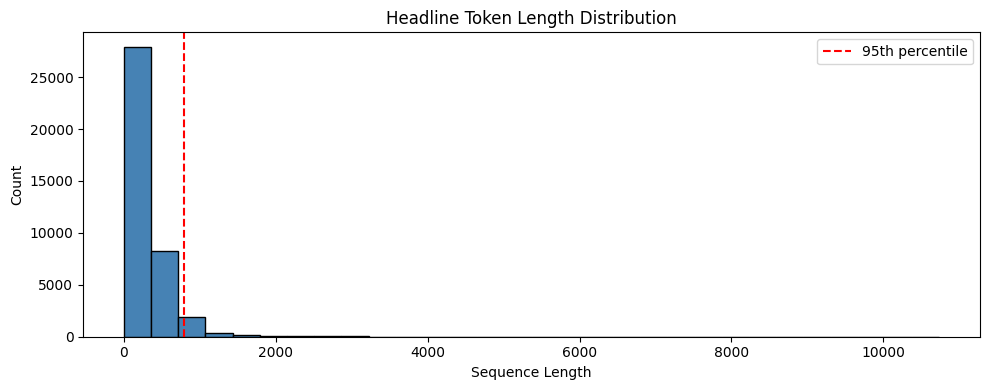

In [96]:
import numpy as np
import matplotlib.pyplot as plt

sequence_lengths = [len(seq) for seq in X_train_seq]

print("Sequence Length Distribution:")
print(f"  Min    : {np.min(sequence_lengths)}")
print(f"  Max    : {np.max(sequence_lengths)}")
print(f"  Mean   : {np.mean(sequence_lengths):.2f}")
print(f"  Median : {np.median(sequence_lengths):.2f}")
print(f"  90th % : {np.percentile(sequence_lengths, 90):.2f}")
print(f"  95th % : {np.percentile(sequence_lengths, 95):.2f}")
print(f"  99th % : {np.percentile(sequence_lengths, 99):.2f}")

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(sequence_lengths, bins=30, color='steelblue', edgecolor='black')
plt.axvline(np.percentile(sequence_lengths, 95), color='red',
            linestyle='--', label='95th percentile')
plt.title('Headline Token Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### Padding

In [97]:
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f'MAX_LEN = {MAX_LEN}')

MAX_LEN = 795


In [98]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Padding ───────────────────────────────────────────────────────────
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

In [99]:
print(f'X_train_pad : {X_train_pad.shape}')
print(f'X_val_pad   : {X_val_pad.shape}')
print(f'X_test_pad  : {X_test_pad.shape}')

X_train_pad : (38901, 795)
X_val_pad   : (8336, 795)
X_test_pad  : (8337, 795)


**CNN + BiLSTM Architecture**

In [100]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, SpatialDropout1D,
    Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM,
    Dense, Dropout, BatchNormalization,
    Concatenate
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

In [101]:
# Safe vocab size — avoids embedding unused index space
actual_vocab_size = min(vocab_size, len(tokenizer.word_index) + 1)
EMB_DIM = 64

In [102]:
# ── Input ─────────────────────────────────────────────────────────────
inp = Input(shape=(MAX_LEN,))

# ── Shared Embedding ──────────────────────────────────────────────────
embed = Embedding(
    input_dim=actual_vocab_size,
    output_dim=EMB_DIM,
    #input_length=MAX_LEN
)(inp)

embed = SpatialDropout1D(0.2)(embed)   # drops entire embedding dims — same as original

# ══ PATH A: Multi-kernel CNN ════════════════════════════════════════
# Captures local n-gram patterns at different scales
conv2 = Conv1D(64, kernel_size=2, activation='relu', padding='same')(embed)
conv2 = BatchNormalization()(conv2)
conv2 = GlobalMaxPooling1D()(conv2)

conv3 = Conv1D(64, kernel_size=3, activation='relu', padding='same')(embed)
conv3 = BatchNormalization()(conv3)
conv3 = GlobalMaxPooling1D()(conv3)

conv5 = Conv1D(64, kernel_size=5, activation='relu', padding='same')(embed)
conv5 = BatchNormalization()(conv5)
conv5 = GlobalMaxPooling1D()(conv5)

cnn_out = Concatenate()([conv2, conv3, conv5])  # shape: (None, 192)

# ══ PATH B: BiLSTM on full sequence ════════════════════════════════
# Reads all 30 tokens — captures word order and long-range context
# This is the key fix: BiLSTM gets real sequential input, not 3 pooled scalars
lstm_out = Bidirectional(
    LSTM(
        64,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    )
)(embed)                              # shape: (None, 128)

# ══ Merge both paths ══════════════════════════════════════════════
merged = Concatenate()([cnn_out, lstm_out])  # shape: (None, 320)

# ── Classification head ───────────────────────────────────────────────
x = Dropout(0.4)(merged)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)

# ── Output ───────────────────────────────────────────────────────────
out = Dense(1, activation='sigmoid')(x)

# ── Build ─────────────────────────────────────────────────────────────
model = Model(inputs=inp, outputs=out, name='HybridCNN_BiLSTM_Fixed')


In [103]:
# AUC-ROC is more stable than accuracy for binary classification.
# EarlyStopping will monitor val_auc, not val_loss.
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')   # ← KEY addition
    ]
)

In [104]:
model.summary()

Model: "HybridCNN_BiLSTM_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 795)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 795, 64)   │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 795, 64)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 795, 64)   │      8,256 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 795, 64)   │     12,352 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 795, 64)   │     20,544 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 795, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 795, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 795, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     66,048 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 320)       │          0 │ concatenate[0][0… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 320)       │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     20,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,408,577 (5.37 MB)

 Trainable params: 1,408,193 (5.37 MB)

 Non-trainable params: 384 (1.50 KB)

In [105]:
print(f'\nTotal parameters: {model.count_params():,}')


Total parameters: 1,408,577


**Tarining the Model**

In [106]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [107]:
# ── 1. EarlyStopping — monitors val_auc now ───────────────────────────
early_stop = EarlyStopping(
    monitor='val_auc',       # ← was val_loss in original
    mode='max',              # ← higher AUC = better
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [108]:
# ── 2. ModelCheckpoint ────────────────────────────────────────────────
checkpoint = ModelCheckpoint(
    filepath='best_model_fixed.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [109]:
# ── 3. ReduceLROnPlateau ──────────────────────────────────────────────
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [110]:
print('Callbacks ready.')
print('EarlyStopping : monitors val_auc (max) — patience=4')
print('ReduceLROnPlateau : monitors val_loss — halves LR after 2 stall epochs')

Callbacks ready.
EarlyStopping : monitors val_auc (max) — patience=4
ReduceLROnPlateau : monitors val_loss — halves LR after 2 stall epochs


#train

In [111]:
import time

print('=' * 60)
print('Training: Hybrid CNN + BiLSTM')
print('=' * 60)

t0 = time.time()

Training: Hybrid CNN + BiLSTM


In [ ]:
FULL_EPOCHS = 10  # Define the number of epochs for training
BATCH_SIZE = 64   # Define the batch size for training

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),   # ← explicit, not validation_split
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/10
160/608 ━━━━━━━━━━━━━━━━━━━━ 39:56 5s/step - accuracy: 0.5366 - auc: 0.5433 - loss: 1.1084

In [ ]:
train_time = time.time() - t0
print(f'\nTraining complete!')
print(f'  Total epochs run   : {len(history.history["loss"])}')
print(f'  Best val_auc       : {max(history.history["val_auc"]):.4f}')
print(f'  Best val_accuracy  : {max(history.history["val_accuracy"]):.4f}')
print(f'  Training time      : {train_time/60:.1f} min')

In [ ]:
def predict_headline(headline, threshold=0.5):
    """
    Predict whether a news headline is Fake or Real.
    Uses the same minimal preprocessing pipeline as training.
    """
    cleaned = preprocess_text(headline)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob    = model.predict(padded, verbose=0)[0][0]
    label   = 'REAL' if prob > threshold else 'FAKE'
    conf    = prob if prob > threshold else 1 - prob

    print(f'Headline : "{headline[:80]}"')
    print(f'Cleaned  : "{cleaned[:80]}"')
    print(f'Verdict  : {label}  (confidence: {conf*100:.1f}%)')
    bar_real = 'X' * int(prob * 30)
    bar_fake = 'X' * int((1 - prob) * 30)
    print(f'Real  {bar_real:<30} {prob*100:.1f}%')
    print(f'Fake  {bar_fake:<30} {(1-prob)*100:.1f}%')
    print()
    return label, float(prob)


test_headlines = [
    'NASA confirms water ice found near Mars south pole',
    'Federal Reserve holds interest rates steady amid inflation concerns',
    'Scientists CONFIRM vaccines cause autism in new secret study',
    'President secretly signs bill to ban all social media by next week',
]

print('-' * 60)
for h in test_headlines:
    predict_headline(h)
    print('-' * 60)


In [ ]:
your_headline = input('\nEnter a news headline to classify: ')
predict_headline(your_headline)